# Coffee flavor map — Word2Vec (Phase 1)

We turn coffee tasting text into **vectors** (numbers) for each word. Words that appear in similar contexts get **similar vectors**. Then we check neighbors, a small **analogy**, a **similarity table** for flavor words, and a **2D plot**.

In [1]:
# Install Word2Vec library in *this* notebook kernel (no-op if already there)
%pip install -q "gensim>=4.3.0"

import os
import re
import subprocess
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


## Google Colab

If you only uploaded this notebook, **`corpus.txt` is missing**. The next cell clones the repo into `/content/ml-nlp-guide` and moves into the project folder. On your own computer, this cell does nothing.

In [2]:
if Path("/content").is_dir() and not os.environ.get("COFFEE_FLAVOR_MAP_ROOT"):
    _clone = Path("/content/ml-nlp-guide")
    _url = "https://github.com/YOUSEF-ysfxjo/ml-nlp-guide.git"
    _corpus = _clone / "coffee-flavor-map" / "data" / "processed" / "corpus.txt"
    if not _corpus.is_file():
        if not _clone.is_dir():
            subprocess.run(
                ["git", "clone", "--depth", "1", _url, str(_clone)],
                check=True,
                cwd="/content",
            )
        if not _corpus.is_file():
            raise FileNotFoundError(
                f"Expected corpus at {_corpus} after clone. Set COFFEE_FLAVOR_MAP_ROOT if using Drive."
            )
    os.chdir(_clone / "coffee-flavor-map" / "phase1_global")
    print("Colab OK:", Path.cwd())

## Find `corpus.txt`

We need the cleaned text file: **`coffee-flavor-map/data/processed/corpus.txt`**. The code searches from the current folder upward, and on Colab also searches under `/content`. You can override with `COFFEE_FLAVOR_MAP_ROOT`.

In [3]:
_REL_IN_ROOT = Path("data") / "processed" / "corpus.txt"
_REL_IN_PARENT = Path("coffee-flavor-map") / "data" / "processed" / "corpus.txt"


def _colab_bfs_bases(max_depth=5, max_nodes=400):
    """Search under /content (Colab) so nested clones are found."""
    bases = []
    content = Path("/content")
    if not content.is_dir():
        return bases
    seen = set()
    q = deque([(content.resolve(), 0)])
    while q and len(seen) < max_nodes:
        path, depth = q.popleft()
        if path in seen:
            continue
        seen.add(path)
        bases.append(path)
        if depth >= max_depth:
            continue
        try:
            for ch in sorted(path.iterdir()):
                if ch.is_dir() and not ch.name.startswith("."):
                    q.append((ch.resolve(), depth + 1))
        except (OSError, PermissionError):
            pass
    return bases


def _find_corpus_txt():
    env_root = os.environ.get("COFFEE_FLAVOR_MAP_ROOT")
    if env_root:
        root = Path(env_root).expanduser().resolve()
        p = root / _REL_IN_ROOT
        if p.is_file():
            return root, p
    start = Path.cwd().resolve()
    tried = []
    seen_bases = set()
    bases = []
    for b in _colab_bfs_bases() + [start, *start.parents]:
        r = b.resolve()
        if r in seen_bases:
            continue
        seen_bases.add(r)
        bases.append(r)
    for base in bases:
        for rel in (_REL_IN_ROOT, _REL_IN_PARENT):
            p = (base / rel).resolve()
            tried.append(p)
            if p.is_file():
                return p.parent.parent.parent, p
    msg = "corpus.txt not found. Sample paths:\n" + "\n".join(f"  {x}" for x in tried[:40])
    raise FileNotFoundError(msg)


PROJECT_ROOT, file_path = _find_corpus_txt()
MODEL_PATH = PROJECT_ROOT / "phase1_global" / "word2vec.model"
print(f"PROJECT_ROOT = {PROJECT_ROOT}\nfile_path     = {file_path}")

PROJECT_ROOT = /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map
file_path     = /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map/data/processed/corpus.txt


## Load the corpus

Each **line** becomes one sentence (list of tokens). We lowercase, drop punctuation, and keep tokens with length ≥ 2.

In [4]:
def preprocess_line(line):
    line = line.strip().lower()
    line = re.sub(r"[^\w\s-]", " ", line)  # keep letters, digits, _, hyphen
    tokens = line.split()
    return [t for t in tokens if len(t) >= 2]


corpus = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        tokens = preprocess_line(line)
        if tokens:
            corpus.append(tokens)

print(f"Loaded {len(corpus)} sentences. First 3: {corpus[:3]}")

Loaded 5092 sentences. First 3: [['crisply', 'sweet', 'cocoa-toned'], ['lemon', 'blossom', 'roasted', 'cacao', 'nib', 'date', 'rice', 'candy', 'white', 'peppercorn', 'in', 'aroma', 'and', 'cup'], ['savory-tart', 'structure', 'delicate', 'silky', 'mouthfeel']]


## Train Word2Vec and save

- **`vector_size`**: length of each word vector  
- **`window`**: how far left/right the model looks  
- **`min_count`**: ignore very rare words  
- **`sg=1`**: skip-gram (good for rarer words in a small corpus)  

The model file is written next to this notebook under `phase1_global/`.

In [5]:
VECTOR_SIZE = 100
WINDOW = 5
MIN_COUNT = 10
WORKERS = 4
SG = 1  # 1 = skip-gram, 0 = CBOW

model = Word2Vec(
    sentences=corpus,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=SG,
    epochs=5,  # multiple passes over sentences (stable vs single pass)
)
model.save(str(MODEL_PATH))
print(f"Saved {MODEL_PATH} | vocab={len(model.wv):,}")

Saved /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map/phase1_global/word2vec.model | vocab=359


## Nearest words and one analogy

**`most_similar`** = words whose vectors are closest (cosine similarity).  
**Analogy** `positive=[A,B], negative=[C]` ≈ vector **A − C + B**; here we use *berry + chocolate − lemon* as a demo (results depend on your text).

In [6]:
for flavor in ("lemon", "chocolate", "vanilla"):
    try:
        print(f"\nMost similar to '{flavor}':")
        for w, s in model.wv.most_similar(flavor, topn=5):
            print(f"  {w}: {s:.4f}")
    except KeyError:
        print(f"'{flavor}' not in vocabulary")

try:
    print("\nAnalogy: berry + chocolate - lemon ≈")
    for w, s in model.wv.most_similar(positive=["berry", "chocolate"], negative=["lemon"], topn=5):
        print(f"  {w}: {s:.4f}")
except KeyError as e:
    print("Analogy skipped:", e)


Most similar to 'lemon':
  tangerine: 0.9576
  guava: 0.9539
  nectarine: 0.9448
  peach: 0.9440
  honey: 0.9428

Most similar to 'chocolate':
  dark: 0.9251
  fudge: 0.9235
  caramel: 0.9143
  spices: 0.9105
  cherry: 0.9092

Most similar to 'vanilla':
  candied: 0.9958
  salted: 0.9954
  pomelo: 0.9948
  mesquite: 0.9942
  clove: 0.9939

Analogy: berry + chocolate - lemon ≈
  tones: 0.8553
  wood: 0.8489
  cappuccino-scaled: 0.8385
  while: 0.8375
  fruit: 0.8327


## Flavor-word similarity matrix

We pick a **small list** of flavor words (from a wheel-style list). Words not in the vocabulary are skipped. The table shows **cosine similarity** between each pair (1 = same direction, 0 = unrelated).

In [7]:
target_flavors = [
    "lemon", "chocolate", "cocoa", "floral", "nutty",
    "citrus", "berry", "honey", "vanilla", "fruity",
    "caramel", "roasted", "jasmine", "acidic",
]
existing_flavors = [w for w in target_flavors if w in model.wv]
missing = set(target_flavors) - set(existing_flavors)
print(f"Flavor terms in vocab: {len(existing_flavors)} | dropped: {missing or 'none'}")

sim = [[model.wv.similarity(a, b) for b in existing_flavors] for a in existing_flavors]
df_sim = pd.DataFrame(sim, index=existing_flavors, columns=existing_flavors)
display(df_sim.round(3))

print("\nTop neighbor within flavor list:")
for target in existing_flavors:
    others = [w for w in existing_flavors if w != target]
    top = max(others, key=lambda x: model.wv.similarity(target, x))
    sc = model.wv.similarity(target, top)
    print(f"  {target:<10} -> {top:<10} ({sc:.3f})")

Flavor terms in vocab: 13 | dropped: {'acidic'}


,lemon,chocolate,cocoa,floral,nutty,citrus,berry,honey,vanilla,fruity,caramel,roasted,jasmine
lemon,1.000,0.690,0.928,0.158,0.504,0.641,0.741,0.943,0.909,0.137,0.878,0.913,0.932
chocolate,0.690,1.000,0.660,0.416,0.574,0.670,0.775,0.798,0.866,0.196,0.914,0.659,0.739
cocoa,0.928,0.660,1.000,0.200,0.536,0.685,0.773,0.923,0.884,0.171,0.850,0.883,0.922
floral,0.158,0.416,0.200,1.000,0.861,0.687,0.645,0.211,0.299,0.822,0.339,0.083,0.217
nutty,0.504,0.574,0.536,0.861,1.000,0.842,0.831,0.563,0.625,0.863,0.621,0.433,0.545
citrus,0.641,0.670,0.685,0.687,0.842,1.000,0.977,0.672,0.690,0.489,0.722,0.457,0.711
berry,0.741,0.775,0.773,0.645,0.831,0.977,1.000,0.784,0.804,0.449,0.833,0.596,0.798
honey,0.943,0.798,0.923,0.211,0.563,0.672,0.784,1.000,0.976,0.188,0.955,0.928,0.948
vanilla,0.909,0.866,0.884,0.299,0.625,0.690,0.804,0.976,1.000,0.259,0.985,0.909,0.931
fruity,0.137,0.196,0.171,0.822,0.863,0.489,0.449,0.188,0.259,1.000,0.224,0.147,0.146



Top neighbor within flavor list:
  lemon      -> honey      (0.943)
  chocolate  -> caramel    (0.914)
  cocoa      -> lemon      (0.928)
  floral     -> nutty      (0.861)
  nutty      -> fruity     (0.863)
  citrus     -> berry      (0.977)
  berry      -> citrus     (0.977)
  honey      -> vanilla    (0.976)
  vanilla    -> caramel    (0.985)
  fruity     -> nutty      (0.863)
  caramel    -> vanilla    (0.985)
  roasted    -> honey      (0.928)
  jasmine    -> honey      (0.948)


## 2D plot (PCA + KMeans)

**PCA** squeezes the 100-dimensional vectors down to **2** for drawing. **KMeans** groups words into a few clusters (colors) using the *full* vectors. Nearby points are more similar in the original space (roughly).

PCA explained variance ratio: [0.6732128  0.13879561]
Clusters: [('lemon', np.int32(0)), ('chocolate', np.int32(3)), ('cocoa', np.int32(0)), ('floral', np.int32(1)), ('nutty', np.int32(2)), ('citrus', np.int32(2)), ('berry', np.int32(2)), ('honey', np.int32(0)), ('vanilla', np.int32(3)), ('fruity', np.int32(1)), ('caramel', np.int32(3)), ('roasted', np.int32(0)), ('jasmine', np.int32(0))]


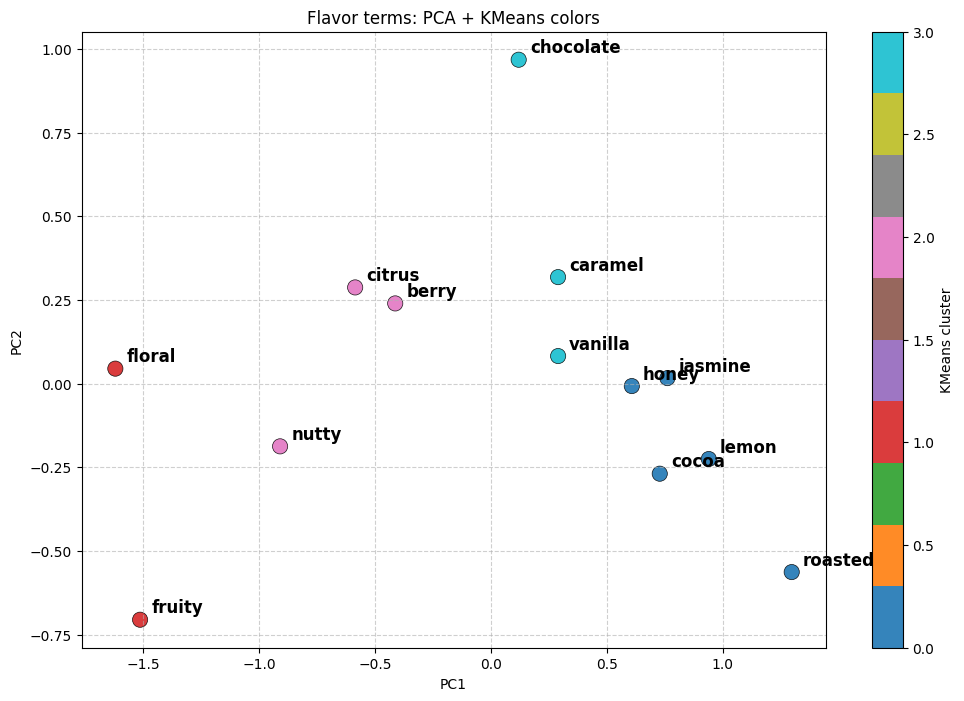

In [8]:
terms_in_vocab = existing_flavors
vectors = np.array([model.wv[t] for t in terms_in_vocab])

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(vectors)

n_clusters = min(4, max(2, len(terms_in_vocab) // 3))
cluster_labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(vectors)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Clusters:", list(zip(terms_in_vocab, cluster_labels)))

plt.figure(figsize=(12, 8))
sc = plt.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=cluster_labels, cmap="tab10", s=120,
    edgecolors="black", linewidths=0.5, alpha=0.9,
)
plt.colorbar(sc, label="KMeans cluster")
for i, word in enumerate(terms_in_vocab):
    plt.annotate(
        word, xy=(coords_2d[i, 0], coords_2d[i, 1]),
        xytext=(8, 5), textcoords="offset points", fontsize=12, fontweight="bold",
    )
plt.title("Flavor terms: PCA + KMeans colors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## How to read the results (simple)

- **`most_similar`**: High scores (near 1.0) mean the model often saw those words in **similar contexts**. They are not always “synonyms”; they can be other review words that co-occur (e.g. texture or structure words).
- **Analogy**: Treat as a **demo**. With short, domain-specific text, top matches are often weak or odd. It improves with more data and tuning.
- **Similarity table**: Values near **1** on the diagonal are expected (word vs itself). **Off-diagonal** highs (e.g. citrus–berry, vanilla–caramel) suggest the model groups those flavor words together in this corpus.
- **PCA plot**: **PC1/PC2** only keep part of the information (see printed *explained variance ratio*). **KMeans** colors are one possible grouping; change `n_clusters` or `random_state` and the colors can change.

*Example run (your numbers may differ slightly): ~5k sentences, vocab ~359, `acidic` often missing with `min_count=10`; first two PCs explained ~69% + ~14% of variance among the listed flavor vectors.*

## Word2Vec vs GloVe (papers + this run)

See **`EMBEDDINGS_COMPARE.md`** in this folder for the full three-way write-up: Word2Vec vs GloVe vs FastText — what each approach **optimizes**, **captured outputs** on this corpus (neighbors, analogy, flavor pairs, PCA), and how to read differences without over-interpreting a small dataset.